# Process 2 — ML with Process Attributes vs Baseline Methods

Compares four approaches **without using any energy/sensor columns** as features:

| Mode | Duration source | Transition source |
|---|---|---|
| `median_baseline` | constant per-activity median | Petri-net stochastic weights |
| `distribution_fit` | fitted distribution (best of lognorm/gamma/…) | Petri-net stochastic weights |
| `petri_heuristic` | fitted distribution | Heuristic Miner PN |
| `petri_inductive` | fitted distribution | Inductive Miner PN |
| `ml_process_attrs` | XGBoost / mean / median — features: `object_attributes` (incl. `total_material`) + `prev_activity` | same ML classifier |

Line **l01** from Process 2 is used as the example.

## 0 · Setup

In [71]:
import os, sys, warnings
os.environ['TQDM_DISABLE'] = '1'
warnings.filterwarnings('ignore')

import logging
logging.getLogger('pm4py').setLevel(logging.ERROR)
logging.captureWarnings(True)

SRC_DIR = os.path.dirname(os.path.abspath('__file__'))
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pm4py
from pm4py.util import constants as pm4py_constants
pm4py_constants.SHOW_PROGRESS_BAR = False
from IPython.display import display
pd.options.mode.chained_assignment = None

print('Setup complete.')

Setup complete.


In [72]:
from modelling_utils import (
    _split_process_datasets,
    comprehensive_simulation_evaluation,
    _plot_short_heatmap,
)
from sim_extractor import extract_process
from sim_modeller import SimModeller
from simulation import ProcessSimulation

print('All src modules imported.')

All src modules imported.


## 1 · Load Process 2 — filter to line l01

In [73]:
from pathlib import Path

EXPERIMENT  = '1'
PROCESS     = 'process_2'
OBJECT_LINE = 'l01'   # one production line
TRAIN_RATIO = 0.70

gold_base = Path(SRC_DIR).parent / 'data' / 'gold' / f'experiment_{EXPERIMENT}' / PROCESS / 'datasets'

event_log_full  = pd.read_parquet(gold_base / 'df_event_log.parquet')
production_plan_full = pd.read_parquet(gold_base / 'df_production_plan.parquet')

print('Event log columns:', event_log_full.columns.tolist())
print('Event log shape  :', event_log_full.shape)
print('Objects          :', event_log_full['object'].unique())

Event log columns: ['timestamp_start', 'timestamp_end', 'activity', 'higher_level_activity', 'object_type', 'object', 'case_id', 'object_attributes']
Event log shape  : (2587, 8)
Objects          : ['l01' 'l02']


In [74]:
# Keep only l01
event_log = event_log_full[event_log_full['object'] == OBJECT_LINE].copy()
event_log = event_log.dropna(subset=['case_id', 'activity', 'timestamp_start', 'timestamp_end'])

print(f'Filtered to {OBJECT_LINE}: {len(event_log)} rows, {event_log["case_id"].nunique()} cases')
print(f'Activities: {sorted(event_log["activity"].unique())}')
display(event_log.head(10))

Filtered to l01: 1299 rows, 48 cases
Activities: ['Fehler Tankanwahl Bestand', 'Grundstellung', 'Leitung zum HSM füllen', 'Leitung zum Vorheizer füllen', 'Materialvalidierung', 'Nachlauf', 'Produktion', 'Spülen auf Gully', 'Spülen mit Wasser', 'Vorwärmen des Warmwasserkreislaufs', 'Warten auf Quelle', 'Warten auf Ziel']


,timestamp_start,timestamp_end,activity,higher_level_activity,object_type,object,case_id,object_attributes
0,2024-11-03 14:03:21,2024-11-04 08:58:21,Grundstellung,l01,l01,l01,shift_2_2024-11-03,"{'mat_id_m01_': 0, 'mat_id_m02_': 0, 'mat_id_m..."
1,2024-11-04 08:58:26,2024-11-04 08:59:01,Vorwärmen des Warmwasserkreislaufs,l01,l01,l01,shift_1_2024-11-04,"{'mat_id_m01_': 8681981, 'mat_id_m02_': 0, 'ma..."
2,2024-11-04 08:59:06,2024-11-04 10:13:56,Warten auf Ziel,l01,l01,l01,shift_1_2024-11-04,"{'mat_id_m01_': 8681981, 'mat_id_m02_': 0, 'ma..."
3,2024-11-04 10:14:01,2024-11-04 10:14:06,Materialvalidierung,l01,l01,l01,shift_1_2024-11-04,"{'mat_id_m01_': 8681982, 'mat_id_m02_': 0, 'ma..."
4,2024-11-04 10:14:11,2024-11-04 10:17:41,Leitung zum Vorheizer füllen,l01,l01,l01,shift_1_2024-11-04,"{'mat_id_m01_': 8681982, 'mat_id_m02_': 0, 'ma..."
5,2024-11-04 10:17:46,2024-11-04 10:17:56,Leitung zum HSM füllen,l01,l01,l01,shift_1_2024-11-04,"{'mat_id_m01_': 8681982, 'mat_id_m02_': 0, 'ma..."
6,2024-11-04 10:18:01,2024-11-04 10:24:11,Produktion,l01,l01,l01,shift_1_2024-11-04,"{'mat_id_m01_': 8681982, 'mat_id_m02_': 0, 'ma..."
7,2024-11-04 10:24:16,2024-11-04 10:26:41,Spülen mit Wasser,l01,l01,l01,shift_1_2024-11-04,"{'mat_id_m01_': 8681982, 'mat_id_m02_': 0, 'ma..."
8,2024-11-04 10:26:46,2024-11-04 10:26:56,Nachlauf,l01,l01,l01,shift_1_2024-11-04,"{'mat_id_m01_': 8681982, 'mat_id_m02_': 0, 'ma..."
9,2024-11-04 10:27:01,2024-11-04 10:27:26,Spülen auf Gully,l01,l01,l01,shift_1_2024-11-04,"{'mat_id_m01_': 8681982, 'mat_id_m02_': 0, 'ma..."


In [75]:
# Inspect object_attributes — should contain mat_id_* keys plus total_material
sample_attrs = event_log['object_attributes'].dropna().iloc[0] if 'object_attributes' in event_log.columns else {}
print('Sample object_attributes:', sample_attrs)

Sample object_attributes: {'mat_id_m01_': 0, 'mat_id_m02_': 0, 'mat_id_m03_': 0, 'total_material': 6123.253770616319}


## 2 · Duration distribution per activity

                                    count  median   mean    std
activity                                                       
Warten auf Ziel                       282    56.0   56.7   38.4
Grundstellung                          38    45.4  329.9  821.7
Produktion                            252     6.8    6.5    1.8
Leitung zum Vorheizer füllen           35     3.4    3.2    0.7
Spülen mit Wasser                      34     2.2    2.3    0.1
Vorwärmen des Warmwasserkreislaufs     13     0.7    0.6    0.2
Spülen auf Gully                       34     0.5    0.5    0.3
Fehler Tankanwahl Bestand              29     0.3    4.8   15.4
Leitung zum HSM füllen                 35     0.2    0.3    0.1
Nachlauf                              252     0.2    0.2    0.0
Materialvalidierung                   250     0.1    0.1    0.1
Warten auf Quelle                      45     0.0    0.6    4.1


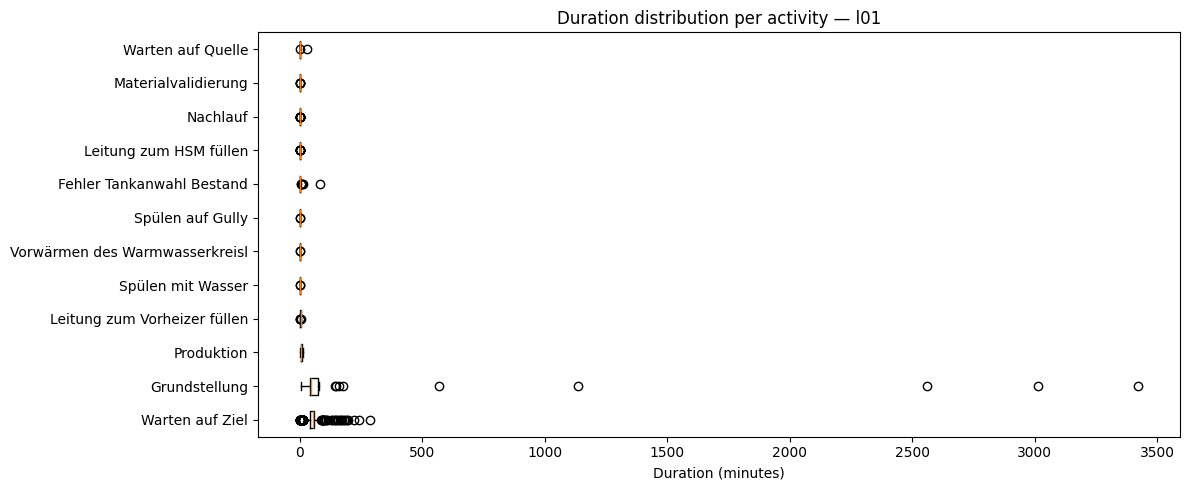

In [76]:
event_log['duration_min'] = (
    pd.to_datetime(event_log['timestamp_end']) - pd.to_datetime(event_log['timestamp_start'])
).dt.total_seconds() / 60.0

dur_stats = (
    event_log.groupby('activity')['duration_min']
    .agg(['count', 'median', 'mean', 'std'])
    .sort_values('median', ascending=False)
)
print(dur_stats.round(1))

fig, ax = plt.subplots(figsize=(12, 5))
activity_order = dur_stats.index.tolist()
bp_data = [event_log[event_log['activity'] == a]['duration_min'].dropna().values for a in activity_order]
ax.boxplot(bp_data, vert=False, labels=[a[:30] for a in activity_order])
ax.set_xlabel('Duration (minutes)')
ax.set_title('Duration distribution per activity — l01')
plt.tight_layout()
plt.show()

## 3 · Train / test split

In [77]:
# Temporal split: sort cases by first timestamp
event_log['timestamp_start'] = pd.to_datetime(event_log['timestamp_start'])
event_log['timestamp_end']   = pd.to_datetime(event_log['timestamp_end'])

case_order = (
    event_log.groupby('case_id')['timestamp_start']
    .min()
    .sort_values()
    .index.tolist()
)
n_train = max(1, int(len(case_order) * TRAIN_RATIO))
train_cases = set(case_order[:n_train])
test_cases  = set(case_order[n_train:])

df_train = event_log[event_log['case_id'].isin(train_cases)].copy()
df_test  = event_log[event_log['case_id'].isin(test_cases)].copy()

# Production plan: one row per case_id (case start/end)
def make_production_plan(el):
    return (
        el.groupby('case_id')
        .agg(
            timestamp_start=('timestamp_start', 'min'),
            timestamp_end=('timestamp_end', 'max'),
            object_attributes=('object_attributes', 'first'),
        )
        .reset_index()
    )

pp_train = make_production_plan(df_train)
pp_test  = make_production_plan(df_test)

print(f'Train: {len(train_cases)} cases, {len(df_train)} events')
print(f'Test : {len(test_cases)} cases, {len(df_test)} events')

Train: 33 cases, 883 events
Test : 15 cases, 416 events


## 4 · Extract process (heuristic miner on training data)

In [78]:
# Extract with heuristic miner — produces stats_df, raw_df, process_models
stats_heuristic, raw_df, pm_heuristic = extract_process(
    df_train,
    mining_algorithm='heuristic',
    optimize_mining_hyperparams=False,
)
print('\nstats_df:')
display(stats_heuristic[['activity', 'duration', 'duration_std', 'dist_name', 'n_events', 'is_start', 'is_end']])

print('\nraw_df columns:', raw_df.columns.tolist())
print('raw_df attr_* columns:', [c for c in raw_df.columns if c.startswith('attr_')])
print('raw_df prev_* columns:', [c for c in raw_df.columns if c.startswith('prev_')])


Processing: l01 (1 objects, one whole-process net)
  Mining algorithm: heuristic
  Found 12 unique activities: ['Grundstellung' 'Vorwärmen des Warmwasserkreislaufs' 'Warten auf Ziel'
 'Materialvalidierung' 'Leitung zum Vorheizer füllen'
 'Leitung zum HSM füllen' 'Produktion' 'Spülen mit Wasser' 'Nachlauf'
 'Spülen auf Gully' 'Fehler Tankanwahl Bestand' 'Warten auf Quelle']
    Grundstellung: best fit = weibull_min (0.5844550101446674, 0.0, 178.00974773019453)
    Vorwärmen des Warmwasserkreislaufs: best fit = lognorm (0.14887146877695792, 0.0, 0.6238080085643007)
    Warten auf Ziel: best fit = weibull_min (1.4034321161703613, 0.0, 62.3606538186368)
    Materialvalidierung: best fit = norm (0.12365591397849464, 0.16309474529158616)
    Leitung zum Vorheizer füllen: best fit = norm (3.1041666666666665, 0.5560327811412774)


    Leitung zum HSM füllen: best fit = norm (0.24652777777777776, 0.04487099994208363)
    Produktion: best fit = weibull_min (4.594773408029717, 0.0, 7.258764040095482)
    Spülen mit Wasser: best fit = norm (2.300724637681159, 0.1384418345981362)
    Nachlauf: best fit = norm (0.16569200779727097, 0.017998231298849306)
    Spülen auf Gully: best fit = lognorm (0.32989829289106276, 0.0, 0.48841459140854526)
    Fehler Tankanwahl Bestand: best fit = gamma (0.42830650319806, 0.0, 21.388221325881048)
    Warten auf Quelle: best fit = norm (14.083333333333334, 13.416666666666668)
    Mining Petri net with 'heuristic' (candidate 1/1): noise=0.2, heur={}
      quality: score=0.7649, fitness=0.9805, precision=0.8013, generalization=0.6776769662451543, simplicity=0.6000000000000001
    Selected params: noise=0.2, heur={} (score=0.7649)
    Petri net: 16 places, 29 transitions, 60 arcs
    Stochastic map: 29 transition weights
    Decision-point weights: 8 decision points, 3 with __END__ proba

,activity,duration,duration_std,dist_name,n_events,is_start,is_end
0,Grundstellung,44.500000,822.854998,weibull_min,26,True,True
1,Vorwärmen des Warmwasserkreislaufs,0.583333,0.106035,lognorm,7,True,False
2,Warten auf Ziel,56.333333,40.391992,weibull_min,191,True,True
3,Materialvalidierung,0.083333,0.150461,norm,169,True,False
4,Leitung zum Vorheizer füllen,3.416667,0.567992,norm,24,False,False
5,Leitung zum HSM füllen,0.250000,0.045836,norm,24,False,False
6,Produktion,6.750000,1.641428,weibull_min,171,False,True
7,Spülen mit Wasser,2.250000,0.141553,norm,23,False,False
8,Nachlauf,0.166667,0.018051,norm,171,True,False
9,Spülen auf Gully,0.500000,0.358641,lognorm,23,False,False



raw_df columns: ['case_id', 'activity', 'object', 'object_type', 'higher_level_activity', 'duration', 'next_activity', 'timestamp_start', 'activity_index', 'hour_of_day', 'day_of_week', 'prev_activity_1', 'prev_duration_1', 'prev_activity_2', 'prev_duration_2', 'attr_mat_id_m01_', 'attr_mat_id_m02_', 'attr_mat_id_m03_', 'attr_total_material']
raw_df attr_* columns: ['attr_mat_id_m01_', 'attr_mat_id_m02_', 'attr_mat_id_m03_', 'attr_total_material']
raw_df prev_* columns: ['prev_activity_1', 'prev_duration_1', 'prev_activity_2', 'prev_duration_2']


In [79]:
# Also extract with inductive miner for the petri_inductive mode
stats_inductive, raw_df_ind, pm_inductive = extract_process(
    df_train,
    mining_algorithm='inductive',
    optimize_mining_hyperparams=False,
)
print('Inductive miner done.')


Processing: l01 (1 objects, one whole-process net)
  Mining algorithm: inductive
  Found 12 unique activities: ['Grundstellung' 'Vorwärmen des Warmwasserkreislaufs' 'Warten auf Ziel'
 'Materialvalidierung' 'Leitung zum Vorheizer füllen'
 'Leitung zum HSM füllen' 'Produktion' 'Spülen mit Wasser' 'Nachlauf'
 'Spülen auf Gully' 'Fehler Tankanwahl Bestand' 'Warten auf Quelle']
    Grundstellung: best fit = weibull_min (0.5844550101446674, 0.0, 178.00974773019453)
    Vorwärmen des Warmwasserkreislaufs: best fit = lognorm (0.14887146877695792, 0.0, 0.6238080085643007)
    Warten auf Ziel: best fit = weibull_min (1.4034321161703613, 0.0, 62.3606538186368)
    Materialvalidierung: best fit = norm (0.12365591397849464, 0.16309474529158616)
    Leitung zum Vorheizer füllen: best fit = norm (3.1041666666666665, 0.5560327811412774)
    Leitung zum HSM füllen: best fit = norm (0.24652777777777776, 0.04487099994208363)
    Produktion: best fit = weibull_min (4.594773408029717, 0.0, 7.2587640400954

## 5 · Train ML model (process attributes + previous activities only)

Features used:
- `attr_*` — flattened from `object_attributes` (mat_id values, `total_material`, …)
- `prev_activity_1`, `prev_activity_2` — label-encoded activity names
- `prev_duration_1`, `prev_duration_2` — duration of previous activities

No sensor / energy columns are used.

In [80]:
# Show which features will be used
attr_cols = [c for c in raw_df.columns if c.startswith('attr_')]
prev_cols = [c for c in raw_df.columns if c.startswith('prev_')]
print('Attribute features:', attr_cols)
print('Previous-activity features:', prev_cols)
print(f'\nTotal ML features: {len(attr_cols) + len(prev_cols)}')
if attr_cols:
    display(raw_df[attr_cols].describe())

Attribute features: ['attr_mat_id_m01_', 'attr_mat_id_m02_', 'attr_mat_id_m03_', 'attr_total_material']
Previous-activity features: ['prev_activity_1', 'prev_duration_1', 'prev_activity_2', 'prev_duration_2']

Total ML features: 8


,attr_mat_id_m01_,attr_mat_id_m02_,attr_mat_id_m03_,attr_total_material
count,8.830000e+02,8.830000e+02,8.830000e+02,883.000000
mean,6.085983e+06,5.889329e+06,5.063448e+06,23242.173153
std,3.976797e+06,4.057492e+06,4.282651e+06,25827.022888
min,0.000000e+00,0.000000e+00,0.000000e+00,2586.458706
25%,0.000000e+00,0.000000e+00,0.000000e+00,13977.639589
50%,8.681590e+06,8.681588e+06,8.681588e+06,17155.600970
75%,8.681590e+06,8.681590e+06,8.681590e+06,19857.716760
max,8.681983e+06,8.681697e+06,8.681697e+06,138529.317881


In [81]:
# Train SimModeller — duration + transitions, no energy data
ml_models = SimModeller(
    model_types=['xgboost', 'mean', 'median'],
    optimize_hyperparams=False,   # set True for tuned results (slower)
    train_transitions=True,       # also learn transitions from process attrs
)
ml_models.train(raw_df, stats_heuristic)
print(ml_models.summary())


[SimModeller] Model types      : ['xgboost', 'mean', 'median']
[SimModeller] Optuna tuning    : False
[SimModeller] Internal val %   : 20%
[SimModeller] Feature columns  : ['attr_mat_id_m01_', 'attr_mat_id_m02_', 'attr_mat_id_m03_', 'attr_total_material', 'prev_activity_1', 'prev_duration_1', 'prev_activity_2', 'prev_duration_2']

  Key: ('Fehler Tankanwahl Bestand', 'l01', 'l01', 'l01')
    Fit size: 15, Val size: 4, Total: 19
    Duration [ xgboost]  MAE=1.002  RMSE=1.612  R²=-0.123
    Duration [    mean]  MAE=6.967  RMSE=7.131  R²=-20.988
    Duration [  median]  MAE=1.083  RMSE=1.776  R²=-0.363
    ✓ Best duration model: xgboost  (val MAE=1.002)
    Transition [ xgboost]  Acc=1.000  F1=1.000
    Transition [    mean]  FAILED: Classification metrics can't handle a mix of binary and continuous targets
    Transition [  median]  Acc=1.000  F1=1.000
    ✓ Best transition model: xgboost  (val Acc=1.000)

  Key: ('Grundstellung', 'l01', 'l01', 'l01')
    Fit size: 20, Val size: 6, Tota

## 6 · Run simulation for each mode & evaluate

In [82]:
def run_and_eval(mode_label, stats_df, production_plan, real_log,
                 sim_mode, process_models=None, ml_models=None):
    """Simulate + evaluate one mode; returns a flat metrics dict."""
    sim_log = ProcessSimulation(
        stats_df,
        production_plan,
        mode=sim_mode,
        process_models=process_models,
        ml_models=ml_models,
        verbose=False,
    ).run()

    if sim_log is None or len(sim_log) == 0:
        print(f'  [{mode_label}] WARNING: empty simulated log')
        return {'mode': mode_label}

    print(f'  [{mode_label}] simulated {len(sim_log)} events for {sim_log["case_id"].nunique()} cases')

    result = comprehensive_simulation_evaluation(
        sim_log, real_log,
        process_models=process_models,
        verbose=False,
    )

    flat = {'mode': mode_label}
    for category, metrics in result.items():
        if isinstance(metrics, dict):
            for k, v in metrics.items():
                flat[f'test_{category}_{k}'] = v
        else:
            flat[f'test_{category}'] = metrics

    return flat

print('run_and_eval helper defined.')

run_and_eval helper defined.


In [83]:
all_results = []

# ── 1. median_baseline — constant per-activity median, PN transitions ──────────
print('Running: median_baseline')
all_results.append(
    run_and_eval(
        'median_baseline', stats_heuristic, pp_test, df_test,
        sim_mode='petri_net_median_duration',
        process_models=pm_heuristic,
    )
)

Running: median_baseline
[DEBUG __init__] mode=petri_net_median_duration, process_models is None: False, process_models len: 1
Building config from 12 activities:
  Config: ('Grundstellung', 'l01', 'l01', 'l01')
    Transitions: {'Nachlauf': 0.038461538461538464, 'Vorwärmen des Warmwasserkreislaufs': 0.15384615384615385, 'Warten auf Ziel': 0.6538461538461539, '__END__': 0.15384615384615385}
    Start: True
  Config: ('Vorwärmen des Warmwasserkreislaufs', 'l01', 'l01', 'l01')
    Transitions: {'Warten auf Ziel': 1.0}
    Start: True
  Config: ('Warten auf Ziel', 'l01', 'l01', 'l01')
    Transitions: {'Fehler Tankanwahl Bestand': 0.09947643979057591, 'Grundstellung': 0.005235602094240838, 'Materialvalidierung': 0.743455497382199, 'Warten auf Quelle': 0.010471204188481676, '__END__': 0.14136125654450263}
    Start: True
  Config: ('Materialvalidierung', 'l01', 'l01', 'l01')
    Transitions: {'Leitung zum Vorheizer füllen': 0.11834319526627218, 'Produktion': 0.6863905325443787, 'Warten auf

In [84]:
# ── 2. distribution_fit — best-fit distribution, statistical (manual) transitions
print('Running: distribution_fit')
all_results.append(
    run_and_eval(
        'distribution_fit', stats_heuristic, pp_test, df_test,
        sim_mode='statistical',
    )
)

Running: distribution_fit
[DEBUG __init__] mode=statistical, process_models is None: True, process_models len: N/A
Building config from 12 activities:
  Config: ('Grundstellung', 'l01', 'l01', 'l01')
    Transitions: {'Nachlauf': 0.038461538461538464, 'Vorwärmen des Warmwasserkreislaufs': 0.15384615384615385, 'Warten auf Ziel': 0.6538461538461539, '__END__': 0.15384615384615385}
    Start: True
  Config: ('Vorwärmen des Warmwasserkreislaufs', 'l01', 'l01', 'l01')
    Transitions: {'Warten auf Ziel': 1.0}
    Start: True
  Config: ('Warten auf Ziel', 'l01', 'l01', 'l01')
    Transitions: {'Fehler Tankanwahl Bestand': 0.09947643979057591, 'Grundstellung': 0.005235602094240838, 'Materialvalidierung': 0.743455497382199, 'Warten auf Quelle': 0.010471204188481676, '__END__': 0.14136125654450263}
    Start: True
  Config: ('Materialvalidierung', 'l01', 'l01', 'l01')
    Transitions: {'Leitung zum Vorheizer füllen': 0.11834319526627218, 'Produktion': 0.6863905325443787, 'Warten auf Quelle': 0.

In [85]:
# ── 3. petri_heuristic — heuristic PN + fitted distributions ─────────────────
print('Running: petri_heuristic')
all_results.append(
    run_and_eval(
        'petri_heuristic', stats_heuristic, pp_test, df_test,
        sim_mode='petri_net',
        process_models=pm_heuristic,
    )
)

Running: petri_heuristic
[DEBUG __init__] mode=petri_net, process_models is None: False, process_models len: 1
Building config from 12 activities:
  Config: ('Grundstellung', 'l01', 'l01', 'l01')
    Transitions: {'Nachlauf': 0.038461538461538464, 'Vorwärmen des Warmwasserkreislaufs': 0.15384615384615385, 'Warten auf Ziel': 0.6538461538461539, '__END__': 0.15384615384615385}
    Start: True
  Config: ('Vorwärmen des Warmwasserkreislaufs', 'l01', 'l01', 'l01')
    Transitions: {'Warten auf Ziel': 1.0}
    Start: True
  Config: ('Warten auf Ziel', 'l01', 'l01', 'l01')
    Transitions: {'Fehler Tankanwahl Bestand': 0.09947643979057591, 'Grundstellung': 0.005235602094240838, 'Materialvalidierung': 0.743455497382199, 'Warten auf Quelle': 0.010471204188481676, '__END__': 0.14136125654450263}
    Start: True
  Config: ('Materialvalidierung', 'l01', 'l01', 'l01')
    Transitions: {'Leitung zum Vorheizer füllen': 0.11834319526627218, 'Produktion': 0.6863905325443787, 'Warten auf Quelle': 0.1952

In [86]:
# ── 4. petri_inductive — inductive PN + fitted distributions ─────────────────
print('Running: petri_inductive')
all_results.append(
    run_and_eval(
        'petri_inductive', stats_inductive, pp_test, df_test,
        sim_mode='petri_net',
        process_models=pm_inductive,
    )
)

Running: petri_inductive
[DEBUG __init__] mode=petri_net, process_models is None: False, process_models len: 1
Building config from 12 activities:
  Config: ('Grundstellung', 'l01', 'l01', 'l01')
    Transitions: {'Nachlauf': 0.038461538461538464, 'Vorwärmen des Warmwasserkreislaufs': 0.15384615384615385, 'Warten auf Ziel': 0.6538461538461539, '__END__': 0.15384615384615385}
    Start: True
  Config: ('Vorwärmen des Warmwasserkreislaufs', 'l01', 'l01', 'l01')
    Transitions: {'Warten auf Ziel': 1.0}
    Start: True
  Config: ('Warten auf Ziel', 'l01', 'l01', 'l01')
    Transitions: {'Fehler Tankanwahl Bestand': 0.09947643979057591, 'Grundstellung': 0.005235602094240838, 'Materialvalidierung': 0.743455497382199, 'Warten auf Quelle': 0.010471204188481676, '__END__': 0.14136125654450263}
    Start: True
  Config: ('Materialvalidierung', 'l01', 'l01', 'l01')
    Transitions: {'Leitung zum Vorheizer füllen': 0.11834319526627218, 'Produktion': 0.6863905325443787, 'Warten auf Quelle': 0.1952

In [87]:
# ── 5. ml_process_attrs — XGBoost on object_attributes + prev_activity ────────
print('Running: ml_process_attrs')
all_results.append(
    run_and_eval(
        'ml_process_attrs', stats_heuristic, pp_test, df_test,
        sim_mode='ml',
        process_models=pm_heuristic,
        ml_models=ml_models,
    )
)

Running: ml_process_attrs
[DEBUG __init__] mode=ml, process_models is None: False, process_models len: 1
Building config from 12 activities:
  Config: ('Grundstellung', 'l01', 'l01', 'l01')
    Transitions: {'Nachlauf': 0.038461538461538464, 'Vorwärmen des Warmwasserkreislaufs': 0.15384615384615385, 'Warten auf Ziel': 0.6538461538461539, '__END__': 0.15384615384615385}
    Start: True
  Config: ('Vorwärmen des Warmwasserkreislaufs', 'l01', 'l01', 'l01')
    Transitions: {'Warten auf Ziel': 1.0}
    Start: True
  Config: ('Warten auf Ziel', 'l01', 'l01', 'l01')
    Transitions: {'Fehler Tankanwahl Bestand': 0.09947643979057591, 'Grundstellung': 0.005235602094240838, 'Materialvalidierung': 0.743455497382199, 'Warten auf Quelle': 0.010471204188481676, '__END__': 0.14136125654450263}
    Start: True
  Config: ('Materialvalidierung', 'l01', 'l01', 'l01')
    Transitions: {'Leitung zum Vorheizer füllen': 0.11834319526627218, 'Produktion': 0.6863905325443787, 'Warten auf Quelle': 0.1952662721

## 7 · Comparison heatmap

In [88]:
evaluation_results_df = pd.DataFrame(all_results)
display(evaluation_results_df[['mode', 'test_overall_error']].sort_values('test_overall_error'))

,mode,test_overall_error
0,median_baseline,0.350586
1,distribution_fit,0.399276
3,petri_inductive,0.410414
2,petri_heuristic,0.426722
4,ml_process_attrs,0.481682


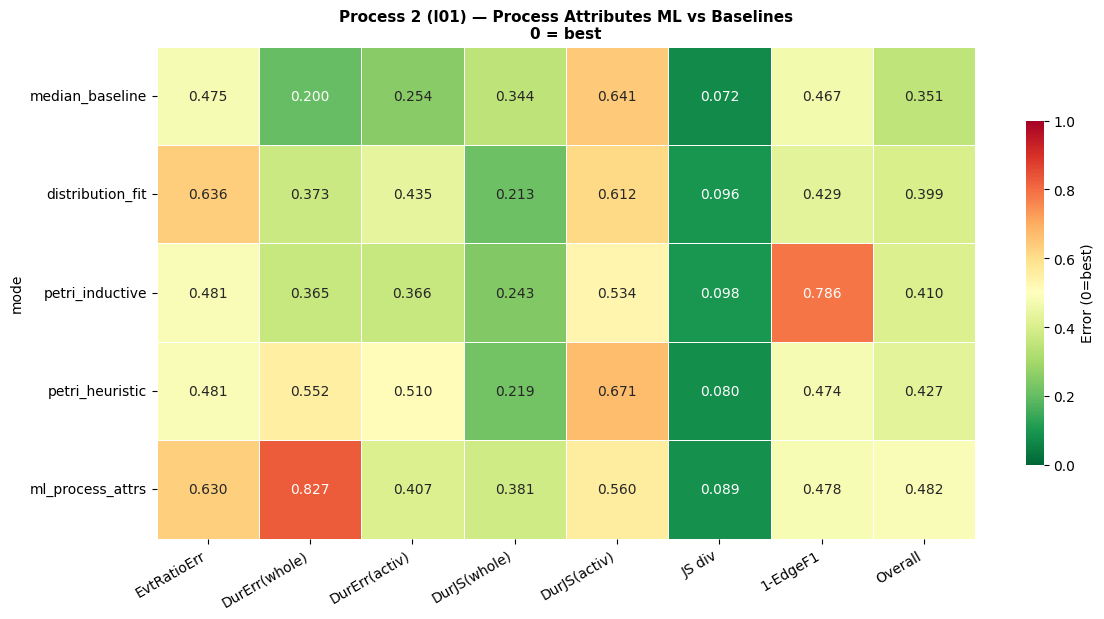


Process 2 (l01) — Process Attributes ML vs Baselines
------------------------------------------------------------
                  EvtRatioErr  DurErr(whole)  DurErr(activ)  DurJS(whole)  DurJS(activ)  JS div  1-EdgeF1  Overall
mode                                                                                                              
median_baseline        0.4750         0.2003         0.2545        0.3439        0.6415  0.0722    0.4667   0.3506
distribution_fit       0.6364         0.3734         0.4347        0.2131        0.6124  0.0964    0.4286   0.3993
petri_inductive        0.4815         0.3645         0.3662        0.2428        0.5343  0.0978    0.7857   0.4104
petri_heuristic        0.4815         0.5519         0.5097        0.2193        0.6711  0.0798    0.4737   0.4267
ml_process_attrs       0.6296         0.8272         0.4072        0.3811        0.5597  0.0886    0.4783   0.4817


In [89]:
_plot_short_heatmap(
    evaluation_results_df,
    title='Process 2 (l01) — Process Attributes ML vs Baselines',
    split='test',
)

## 8 · Per-activity breakdown

In [90]:
# Duration error per activity: compare real vs simulated median duration
def activity_duration_table(mode_label, stats_df, production_plan, real_log,
                             sim_mode, process_models=None, ml_models=None):
    sim_log = ProcessSimulation(
        stats_df, production_plan,
        mode=sim_mode, process_models=process_models, ml_models=ml_models,
        verbose=False,
    ).run()
    if sim_log is None or len(sim_log) == 0:
        return pd.DataFrame()

    real_act = (
        real_log.assign(_d=(pd.to_datetime(real_log['timestamp_end']) -
                            pd.to_datetime(real_log['timestamp_start'])).dt.total_seconds() / 60)
        .groupby('activity')['_d'].median()
        .rename('real_median_min')
    )
    sim_act = (
        sim_log.assign(_d=(pd.to_datetime(sim_log['timestamp_end']) -
                           pd.to_datetime(sim_log['timestamp_start'])).dt.total_seconds() / 60)
        .groupby('activity')['_d'].median()
        .rename(f'{mode_label}_median_min')
    )
    return pd.concat([real_act, sim_act], axis=1)


tables = {}
for label, mode, pm, ml in [
    ('median_baseline', 'petri_net_median_duration', pm_heuristic, None),
    ('distribution_fit', 'statistical',              None,         None),
    ('petri_heuristic',  'petri_net',                pm_heuristic, None),
    ('ml_process_attrs', 'ml',                       pm_heuristic, ml_models),
]:
    tables[label] = activity_duration_table(label, stats_heuristic, pp_test, df_test, mode, pm, ml)

# Merge all into one summary table
from functools import reduce
all_acts = reduce(lambda a, b: a.join(b.drop(columns=['real_median_min'], errors='ignore'), how='outer'),
                  tables.values())
print('Per-activity median duration comparison (minutes):')
display(all_acts.round(1))

[DEBUG __init__] mode=petri_net_median_duration, process_models is None: False, process_models len: 1
Building config from 12 activities:
  Config: ('Grundstellung', 'l01', 'l01', 'l01')
    Transitions: {'Nachlauf': 0.038461538461538464, 'Vorwärmen des Warmwasserkreislaufs': 0.15384615384615385, 'Warten auf Ziel': 0.6538461538461539, '__END__': 0.15384615384615385}
    Start: True
  Config: ('Vorwärmen des Warmwasserkreislaufs', 'l01', 'l01', 'l01')
    Transitions: {'Warten auf Ziel': 1.0}
    Start: True
  Config: ('Warten auf Ziel', 'l01', 'l01', 'l01')
    Transitions: {'Fehler Tankanwahl Bestand': 0.09947643979057591, 'Grundstellung': 0.005235602094240838, 'Materialvalidierung': 0.743455497382199, 'Warten auf Quelle': 0.010471204188481676, '__END__': 0.14136125654450263}
    Start: True
  Config: ('Materialvalidierung', 'l01', 'l01', 'l01')
    Transitions: {'Leitung zum Vorheizer füllen': 0.11834319526627218, 'Produktion': 0.6863905325443787, 'Warten auf Quelle': 0.1952662721893

    ML transitions: {'Leitung zum Vorheizer füllen': 0.003992282319813967, 'Produktion': 0.7016928195953369, 'Warten auf Quelle': 0.2943149209022522}
    Selected next activity: Produktion
    Processing activity 5: Produktion
    Looking for transitions from: Produktion
    Statistical transitions: {'Materialvalidierung': 0.005847953216374269, 'Nachlauf': 0.847953216374269, 'Spülen mit Wasser': 0.13450292397660818, '__END__': 0.011695906432748537}
    Selected next activity: Nachlauf
    Processing activity 6: Nachlauf
    Looking for transitions from: Nachlauf
    ML transitions: {'Spülen auf Gully': 0.004329800605773926, 'Warten auf Ziel': 0.9956701993942261}
    Selected next activity: Warten auf Ziel
    Processing activity 7: Warten auf Ziel
    Looking for transitions from: Warten auf Ziel
    Statistical transitions: {'Fehler Tankanwahl Bestand': 0.09947643979057591, 'Grundstellung': 0.005235602094240838, 'Materialvalidierung': 0.743455497382199, 'Warten auf Quelle': 0.01047120

,real_median_min,median_baseline_median_min,distribution_fit_median_min,petri_heuristic_median_min,ml_process_attrs_median_min
activity,,,,,
Fehler Tankanwahl Bestand,0.3,0.3,2.2,5.6,4.9
Grundstellung,46.0,44.5,93.1,53.2,45.7
Leitung zum HSM füllen,0.2,NaN,0.2,NaN,0.2
Leitung zum Vorheizer füllen,3.4,NaN,3.3,NaN,3.4
Materialvalidierung,0.1,0.1,0.2,0.1,0.1
Nachlauf,0.2,0.2,0.2,0.2,0.2
Produktion,6.8,6.8,6.5,6.6,6.7
Spülen auf Gully,0.5,0.5,0.8,0.4,NaN
Spülen mit Wasser,2.3,2.2,2.3,2.4,2.3


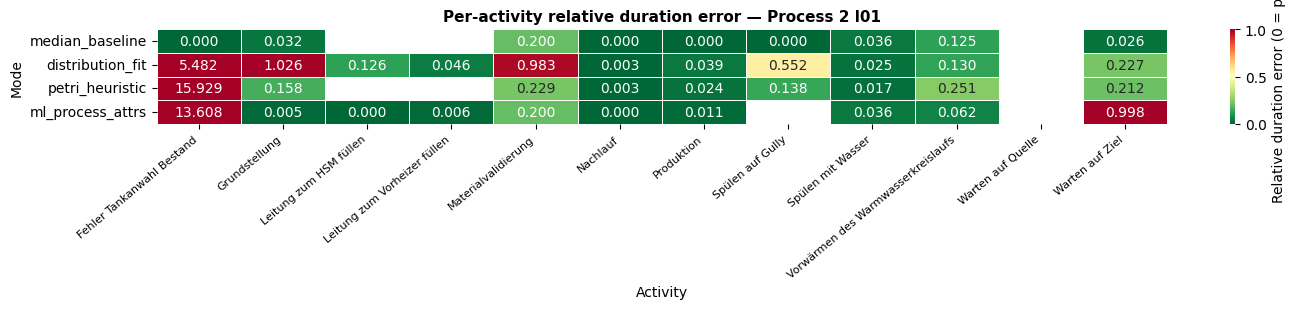

In [91]:
# Heatmap of per-activity relative duration error
err_df = pd.DataFrame(index=all_acts.index)
real_col = all_acts['real_median_min']
for col in all_acts.columns:
    if col == 'real_median_min':
        continue
    mode_name = col.replace('_median_min', '')
    err_df[mode_name] = ((all_acts[col] - real_col) / real_col.replace(0, np.nan)).abs()

err_df = err_df.T   # modes as rows, activities as columns

fig, ax = plt.subplots(figsize=(max(8, len(err_df.columns) * 1.2), max(3, len(err_df) * 0.8)))
sns.heatmap(
    err_df.round(3), annot=True, fmt='.3f',
    cmap='RdYlGn_r', vmin=0, vmax=1,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Relative duration error (0 = perfect)'},
    ax=ax,
)
ax.set_title('Per-activity relative duration error — Process 2 l01',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Activity')
ax.set_ylabel('Mode')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

## 9 · SHAP feature importance — duration models

In [92]:
import shap

MIN_SAMPLES_SHAP = 10

def _fname(col):
    return (col.replace('attr_', '')
               .replace('prev_activity_', 'prev act ')
               .replace('prev_duration_', 'prev dur ')
               .replace('_', ' ').strip())

# Collect XGBoost duration models with enough training data
shap_items = []
for key, (model, feature_cols, model_type) in ml_models.duration_models.items():
    activity = key[0]
    if model_type != 'xgboost':
        print(f'  [{activity}] model_type={model_type} — skipping')
        continue
    group = raw_df[raw_df['activity'] == activity]
    if len(group) < MIN_SAMPLES_SHAP:
        print(f'  [{activity}] only {len(group)} samples — skipping')
        continue
    X = ml_models._build_X(group, feature_cols)
    shap_items.append((activity, model, X, feature_cols))

print(f'\n{len(shap_items)} activities to plot:')
for act, _, X, _ in shap_items:
    print(f'  {act!r}: {len(X)} samples')

  [Grundstellung] model_type=median — skipping
  [Leitung zum HSM füllen] model_type=median — skipping
  [Leitung zum Vorheizer füllen] model_type=median — skipping
  [Materialvalidierung] model_type=median — skipping
  [Nachlauf] model_type=median — skipping
  [Vorwärmen des Warmwasserkreislaufs] model_type=mean — skipping

6 activities to plot:
  'Fehler Tankanwahl Bestand': 19 samples
  'Produktion': 171 samples
  'Spülen auf Gully': 23 samples
  'Spülen mit Wasser': 23 samples
  'Warten auf Quelle': 35 samples
  'Warten auf Ziel': 191 samples


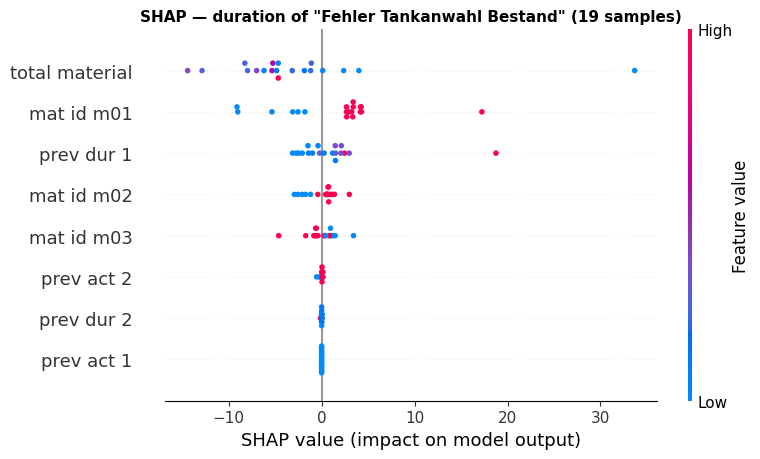

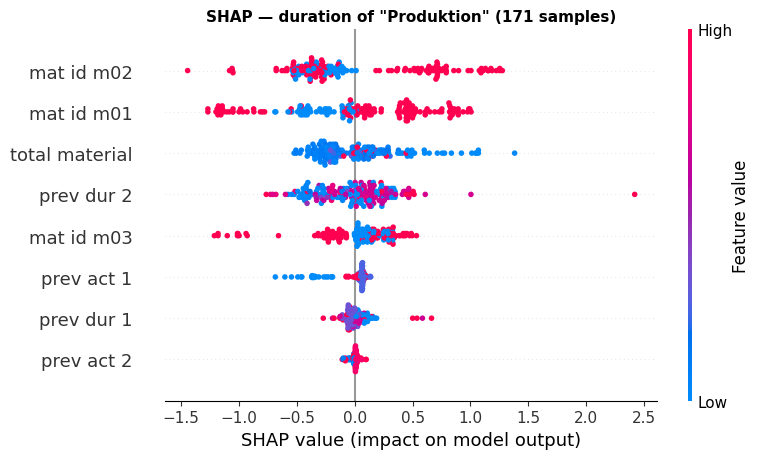

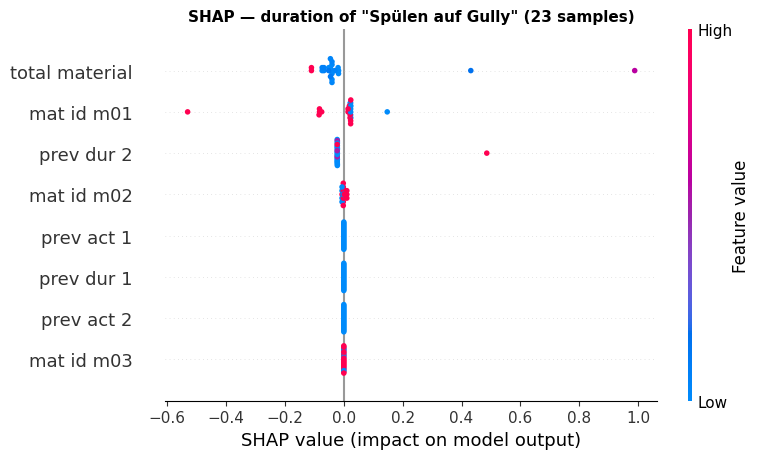

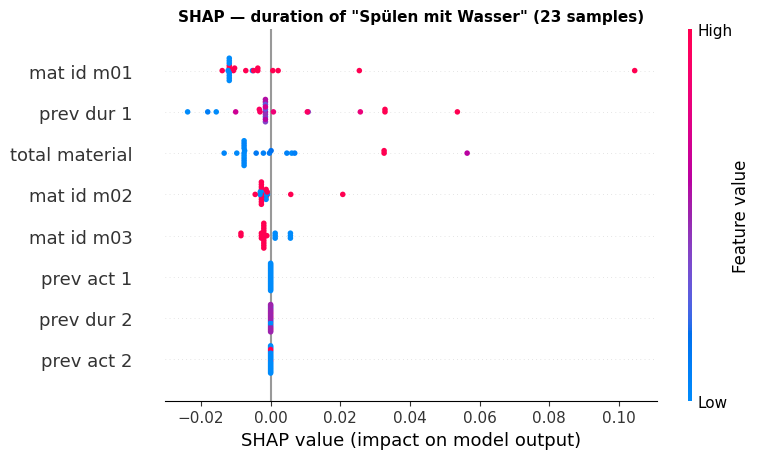

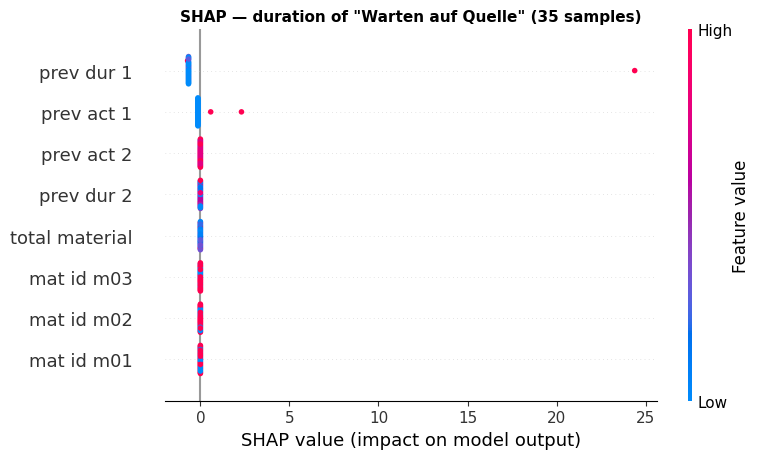

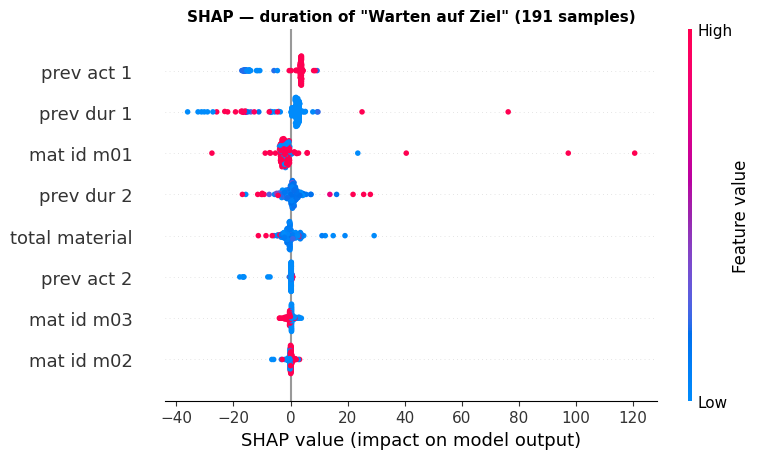

In [93]:
for activity, model, X, feature_cols in shap_items:
    booster = model.get_booster()
    dmat = xgb.DMatrix(X)
    # pred_contribs=True gives exact Tree SHAP values natively — no SHAP version issues
    contribs = booster.predict(dmat, pred_contribs=True)
    sv = contribs[:, :-1]   # last column is the bias term
    readable = [_fname(c) for c in X.columns]

    shap.summary_plot(sv, X.values, feature_names=readable, plot_type='dot', show=False)
    plt.title(f'SHAP — duration of "{activity}" ({len(X)} samples)',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()